In [1]:
import pandas as pd
from datetime import datetime

## Read training and test datasets

In [4]:
# helper function for reading datatset
def read_data(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d') # convert it to datatime

    return df

In [6]:
df_train = read_data('data/kospi_train.csv')
df_test = read_data('data/kospi_test.csv')

len(df_train), len(df_test)

(986, 244)

In [8]:
# the training dataset has daily KOSPI index from 2019 to 2022
df_train

,Date,Open,Low,High,Close,Volume
0,2019-01-02,2050.550049,2004.270020,2053.449951,2010.000000,326400
1,2019-01-03,2011.810059,1991.650024,2014.719971,1993.699951,428000
2,2019-01-04,1992.400024,1984.530029,2011.560059,2010.250000,409000
3,2019-01-07,2034.239990,2030.900024,2048.060059,2037.099976,440200
4,2019-01-08,2038.680054,2023.589966,2042.699951,2025.270020,397800
...,...,...,...,...,...,...
981,2022-12-23,2325.860107,2311.899902,2333.080078,2313.689941,367000
982,2022-12-26,2312.540039,2304.199951,2321.919922,2317.139893,427600
983,2022-12-27,2327.520020,2321.479980,2335.989990,2332.790039,448300
984,2022-12-28,2296.449951,2276.899902,2296.449951,2280.449951,405700


In [10]:
# the test dataset has daily KOSPI index in 2023
df_test

,Date,Open,Low,High,Close,Volume
0,2023-01-02,2249.949951,2222.370117,2259.879883,2225.669922,346100
1,2023-01-03,2230.979980,2180.669922,2230.979980,2218.679932,410000
2,2023-01-04,2205.979980,2198.820068,2260.060059,2255.979980,412700
3,2023-01-05,2268.199951,2252.969971,2281.389893,2264.649902,430800
4,2023-01-06,2253.399902,2253.270020,2300.620117,2289.969971,398300
...,...,...,...,...,...,...
239,2023-12-21,2598.370117,2587.159912,2610.810059,2600.020020,578300
240,2023-12-22,2617.719971,2599.510010,2621.370117,2599.510010,466000
241,2023-12-26,2609.439941,2594.649902,2612.139893,2602.590088,439500
242,2023-12-27,2599.350098,2590.080078,2613.500000,2613.500000,349700


## Part 1. Train regression models to predict the next day's `close` using `Open`, `Low`, `High`, `Close`, `Volume` of previous days as predictors using *only* df_train. Cross-validate to select the best model. Evaluate the accuracy of your model using `df_test`.


In [13]:
# 필요한 패키지 로드 (Lab3)
import numpy as np
from matplotlib.pyplot import subplots
import seaborn as sns

%load_ext autoreload
%autoreload 2

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from ISLP.models import ModelSpec as MS, summarize, poly

In [15]:
# Training 단계 
ic = pd.DataFrame({'intercept': np.ones(df_train.shape[0])})
nodate = df_train.drop('Date', axis = 1)
X = pd.concat([ic, nodate], axis = 1)
X = X[:-1]

# reset_index를 하지 않는 경우 y의 인덱스가 1부터 설정되어 X의 데이터와 맞지 않음 
y = df_train['Close'][1:]
y = y.reset_index(drop=True)

model = sm.OLS(y, X)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Close   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 4.372e+04
Date:                Fri, 02 May 2025   Prob (F-statistic):               0.00
Time:                        21:03:37   Log-Likelihood:                -4705.0
No. Observations:                 985   AIC:                             9422.
Df Residuals:                     979   BIC:                             9451.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      6.8304      5.505      1.241      0.215      -3.972      17.632
Open          -0.1428      0.096     -1.491      0.136      -0.331       0.045
Low            0.0519      0.100      0.519      0.604      -0.144       0.248
High           0.2764      0.103      2.675      0.008       0.074       0.479
Close          0.8094      0.095      8.529      0.000       0.623       0.996
Volume      3.742e-06   2.88e-06      1.297      0.195   -1.92e-06     9.4e-06
==============================================================================
Omnibus:                       72.852   Durbin-Watson:                   1.894
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              174.363
Skew:                          -0.419   Prob(JB):                     1.37e-38
Kurtosis:                       4.883   Cond. No.                     5.03e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.03e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [17]:
from sklearn.model_selection import train_test_split, cross_validate, KFold, ShuffleSplit
from sklearn.metrics import *  # r2_score를 사용하기 위해
from ISLP.models import sklearn_sm  # cross validation을 위해

# cross_validate 함수를 사용하여 LOOCV와 k 를 2부터 100까지 바꾸어 가면서 MSE가 가장 적은 k 값을 찾음
model = sklearn_sm(sm.OLS)
M_CV = cross_validate(model, X, y, cv=X.shape[0])
cv_error = np.mean(M_CV['test_score'])
opt_k = X.shape[0]

for k in range(2,100):
    M_CV = cross_validate(model, X, y, cv=k)
    err = np.mean(M_CV['test_score'])
    if (cv_error > err):
        cv_error = err 
        opt_k = k

print(f"opt = {opt_k}") 

opt = 7


In [19]:
# K-fold 방법으로 train데이터를 활용하여 모델 학습
cv = KFold(n_splits=opt_k)
model = sm.OLS
for train_index, test_index in cv.split(X):
    X_train, X_test = X.loc[train_index], X.loc[test_index]
    y_train, y_test = y[train_index], y[test_index] 
    result1 = model(y_train, X_train).fit() # 모델학습
    pred_y = result1.get_prediction(X_test).predicted

print(result1.summary())
summarize(result1)

                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 4.297e+04
Date:                Fri, 02 May 2025   Prob (F-statistic):               0.00
Time:                        21:03:59   Log-Likelihood:                -4035.4
No. Observations:                 845   AIC:                             8083.
Df Residuals:                     839   BIC:                             8111.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      6.5871      5.577      1.181      0.2

,coef,std err,t,P>|t|
intercept,6.587100,5.577000,1.181,0.238
Open,-0.163300,0.101000,-1.619,0.106
Low,0.055900,0.105000,0.531,0.596
High,0.301700,0.108000,2.790,0.005
Close,0.801300,0.100000,7.985,0.000
Volume,0.000002,0.000003,0.751,0.453


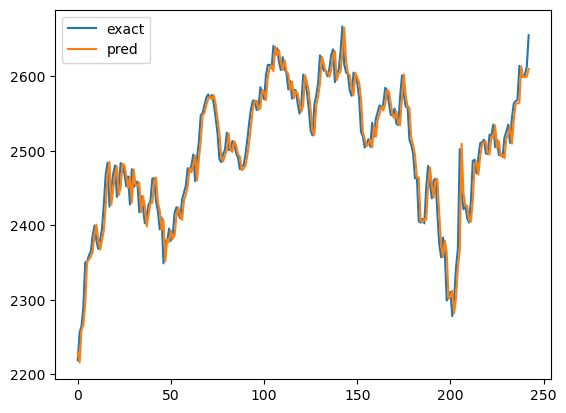


r2 score = 0.9230687201400053


In [21]:
# 테스트 데이터로 모델 검증 (예측값 얻기)
ic = pd.DataFrame({'intercept': np.ones(df_test.shape[0])})
nodate = df_test.drop('Date', axis = 1)
new_X = pd.concat([ic, nodate], axis = 1)
new_X = new_X[:-1]

new_y = df_test['Close'][1:]
new_y = new_y.reset_index(drop=True) # 정답

new_pred = result1.get_prediction(new_X)   # 학습된 모델을 사용하여 예측
pred_y = pd.DataFrame(new_pred.predicted)  # 예측한 y 값

from matplotlib import pyplot as plt
# 정답과 예측값을 비교하여 그래프로 표시
x = range(len(new_y)) 
plt.plot(x, new_y.to_numpy(), label='exact')
plt.plot(x, pred_y.to_numpy(), label='pred')
plt.legend(loc="best")
plt.show()

score = r2_score(new_y.to_numpy(), pred_y.to_numpy())
print(f'\nr2 score = {score}')

## Part 2. Extend the regression model by adding some extra features of your choice. You can use any statistics publicly available. 

In [23]:
# 새로운 데이터 추가
# kospi관련 정보를 읽어들인 후 필요한 정보 추출
# kospi_train 데이터에 22-1-3, 22-5-9 자료가 없어 자료를 맞추기 위해서 두 일자의 거래데이터 삭제
new_data = read_data('data/trade_train.csv')
new_data = new_data[:-1]

extra_feature = new_data[['T_value', 'L_turnover_ratio']]
vol = X[['Volume']].to_numpy()
val = new_data[['T_value']].to_numpy()
extra_feature['T_value*volume'] = (vol*val)/10e+09

train_data = pd.concat([X, extra_feature], axis = 1)

C:\Users\admin\AppData\Local\Temp\ipykernel_27988\2982579860.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra_feature['T_value*volume'] = (vol*val)/10e+09


In [25]:
# cross_validate 함수를 사용하여 LOOCV와 k 를 2부터 100까지 바꾸어 가면서 MSE가 가장 적은 k 값을 찾음
model = sklearn_sm(sm.OLS)
M_CV = cross_validate(model, train_data, y, cv=train_data.shape[0])
cv_error = np.mean(M_CV['test_score'])
opt_k = train_data.shape[0]

for k in range(2,100):
    M_CV = cross_validate(model, train_data, y, cv=k)
    err = np.mean(M_CV['test_score'])
    if (cv_error > err):
        cv_error = err 
        opt_k = k

print(f"opt = {opt_k}") 

opt = 7


In [27]:
# K-fold 방법으로 train데이터를 활용하여 모델을 학습
cv = KFold(n_splits=opt_k)
model = sm.OLS
for train_index, test_index in cv.split(train_data):
    X_train, X_test = train_data.loc[train_index], train_data.loc[test_index]
    y_train, y_test = y[train_index], y[test_index] 
    result2 = model(y_train, X_train).fit() # 모델학습
    pred_y = result2.get_prediction(X_test).predicted

print(result2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 2.692e+04
Date:                Fri, 02 May 2025   Prob (F-statistic):               0.00
Time:                        21:04:30   Log-Likelihood:                -4032.9
No. Observations:                 845   AIC:                             8084.
Df Residuals:                     836   BIC:                             8126.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
intercept            4.8051     10.142  

C:\Users\admin\AppData\Local\Temp\ipykernel_27988\3865062366.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra_feature['T_value*volume'] = (new_X[['Volume']].to_numpy()*new_data[['T_value']].to_numpy())/10e+09


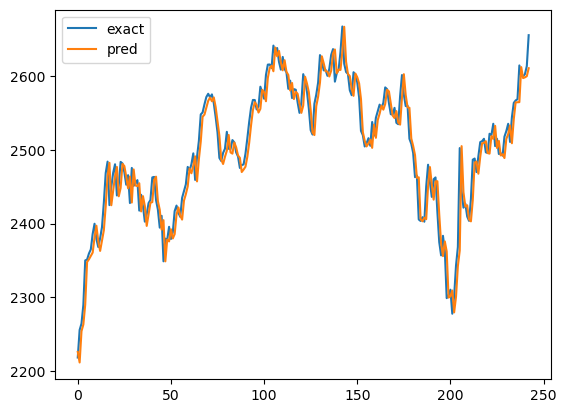


r2 score = 0.9217639117330978


In [29]:
# 테스트 데이터 생성
new_data = read_data('data/trade_test.csv')
new_data = new_data[:-1]

extra_feature = new_data[['T_value', 'L_turnover_ratio']]
extra_feature['T_value*volume'] = (new_X[['Volume']].to_numpy()*new_data[['T_value']].to_numpy())/10e+09

test_data = pd.concat([new_X, extra_feature], axis = 1)  # extra features를 포함한 테스트 데이터

new_pred = result2.get_prediction(test_data)   # 학습된 모델을 사용하여 예측
pred_y_ex = pd.DataFrame(new_pred.predicted)      # 예측 값

from matplotlib import pyplot as plt
# 정답과 예측값을 비교하여 그래프로 표시
x = range(len(new_y))
plt.plot(x, new_y.to_numpy(), label='exact')
plt.plot(x, pred_y_ex.to_numpy(), label='pred')
plt.legend(loc="best")
plt.show()

score = r2_score(new_y.to_numpy(), pred_y_ex.to_numpy())
print(f'\nr2 score = {score}')